__Fix Formatting__

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv('solar_system.csv')

print(f'Before transposing: {df.shape}')

Before transposing: (20, 11)


In [3]:
df = df.set_index("Attribute").T   # Sets the 'Attribute' column as the DataFrame index
                                   # Transposes rows to columns so each row = one planet
print(f'After Transpose: {df.shape}')

df.index.name = "Planet"   # Renames the index to Planet
df.reset_index(inplace=True)   # Converts index (planets) back into a column
df.columns.name = None   # Removes leftover column name metadata
print(f'After reset_index: {df.shape}')

After Transpose: (10, 20)
After reset_index: (10, 21)


The new shape isn’t (11, 20) because reset_index() adds one more column, the new "Planet" column.

In [4]:
print(df.columns)

Index(['Planet', 'Mass (10^24kg)', 'Diameter (km)', 'Density (kg/m^3)',
       'Gravity (m/s^2)', 'Escape Velocity (km/s)', 'Rotation Period (hours)',
       'Length of Day (hours)', 'Distance from Sun (10^6 km)',
       'Perihelion (10^6 km)', 'Aphelion (10^6 km)', 'Orbital Period (days)',
       'Orbital Velocity (km/s)', 'Orbital Inclination (deg)',
       'Orbital Eccentricity', 'Obliquity to Orbit (deg)',
       'Mean Temperature (C)', 'Surface Pressure (bars)', 'Number of Moons',
       'Ring System?', 'Global Magnetic Field?'],
      dtype='object')


In [5]:
with_units = [col for col in df.columns if "(" in col]
without_units = [col for col in df.columns if "(" not in col]

print(f'Columns with units({len(with_units)}):\n', with_units)
print(f'\nColumns without units({len(without_units)}):\n', without_units)

Columns with units(16):
 ['Mass (10^24kg)', 'Diameter (km)', 'Density (kg/m^3)', 'Gravity (m/s^2)', 'Escape Velocity (km/s)', 'Rotation Period (hours)', 'Length of Day (hours)', 'Distance from Sun (10^6 km)', 'Perihelion (10^6 km)', 'Aphelion (10^6 km)', 'Orbital Period (days)', 'Orbital Velocity (km/s)', 'Orbital Inclination (deg)', 'Obliquity to Orbit (deg)', 'Mean Temperature (C)', 'Surface Pressure (bars)']

Columns without units(5):
 ['Planet', 'Orbital Eccentricity', 'Number of Moons', 'Ring System?', 'Global Magnetic Field?']


In [6]:
print(df)

    Planet Mass (10^24kg) Diameter (km) Density (kg/m^3) Gravity (m/s^2)  \
0  Mercury          0.330          4879             5429             3.7   
1    Venus           4.87         12104             5243             8.9   
2    Earth           5.97         12756             5514             9.8   
3     Moon          0.073          3475             3340             1.6   
4     Mars          0.642          6792             3934             3.7   
5  Jupiter           1898        142984             1326            23.1   
6   Saturn            568        120536              687             9.0   
7   Uranus           86.8         51118             1270             8.7   
8  Neptune            102         49528             1638            11.0   
9    Pluto         0.0130          2376             1850             0.7   

  Escape Velocity (km/s) Rotation Period (hours) Length of Day (hours)  \
0                    4.3                  1407.6                4222.6   
1              

__Investigate Data Types__

In [7]:
print(df.dtypes)

Planet                         object
Mass (10^24kg)                 object
Diameter (km)                  object
Density (kg/m^3)               object
Gravity (m/s^2)                object
Escape Velocity (km/s)         object
Rotation Period (hours)        object
Length of Day (hours)          object
Distance from Sun (10^6 km)    object
Perihelion (10^6 km)           object
Aphelion (10^6 km)             object
Orbital Period (days)          object
Orbital Velocity (km/s)        object
Orbital Inclination (deg)      object
Orbital Eccentricity           object
Obliquity to Orbit (deg)       object
Mean Temperature (C)           object
Surface Pressure (bars)        object
Number of Moons                object
Ring System?                   object
Global Magnetic Field?         object
dtype: object


In [8]:
for col in df.columns:
    print(col, df[col].apply(type).unique())

Planet [<class 'str'>]
Mass (10^24kg) [<class 'str'>]
Diameter (km) [<class 'str'>]
Density (kg/m^3) [<class 'str'>]
Gravity (m/s^2) [<class 'str'>]
Escape Velocity (km/s) [<class 'str'>]
Rotation Period (hours) [<class 'str'>]
Length of Day (hours) [<class 'str'>]
Distance from Sun (10^6 km) [<class 'str'>]
Perihelion (10^6 km) [<class 'str'>]
Aphelion (10^6 km) [<class 'str'>]
Orbital Period (days) [<class 'str'>]
Orbital Velocity (km/s) [<class 'str'>]
Orbital Inclination (deg) [<class 'str'>]
Orbital Eccentricity [<class 'str'>]
Obliquity to Orbit (deg) [<class 'str'>]
Mean Temperature (C) [<class 'str'>]
Surface Pressure (bars) [<class 'str'>]
Number of Moons [<class 'str'>]
Ring System? [<class 'str'>]
Global Magnetic Field? [<class 'str'>]


The values are of the type <class 'str'>

Strings cannot be used for numerical operations.

__Convert Strings to Numbers__

In [9]:
for col in df.columns:
    if col not in ["Planet", "Ring System?", "Global Magnetic Field?"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [10]:
print(df.dtypes)

Planet                          object
Mass (10^24kg)                 float64
Diameter (km)                    int64
Density (kg/m^3)                 int64
Gravity (m/s^2)                float64
Escape Velocity (km/s)         float64
Rotation Period (hours)        float64
Length of Day (hours)          float64
Distance from Sun (10^6 km)    float64
Perihelion (10^6 km)           float64
Aphelion (10^6 km)             float64
Orbital Period (days)          float64
Orbital Velocity (km/s)        float64
Orbital Inclination (deg)      float64
Orbital Eccentricity           float64
Obliquity to Orbit (deg)       float64
Mean Temperature (C)             int64
Surface Pressure (bars)        float64
Number of Moons                  int64
Ring System?                    object
Global Magnetic Field?          object
dtype: object


The three data types are now object, float64, and int64
- float64: 64-bit floating-point number
- int64: 64-bit integer
- object: strings or mixed data types

The columns Planet, Ring System?, and Global Magnetic Field? are still an object datatype because they contain “Yes/No” strings

__Apply Astropy Units__

In [11]:
def attach_units(col_name, unit, new_col_name):
    """Attach units to a new """
    df[new_col_name] = df[col_name] * unit
    df.drop(columns=[col_name], inplace=True)

attach_units("Mass (10^24kg)", 1e24 * u.kg, "Mass (kg)")
print(df["Mass (kg)"])

0    3.300000e+23
1    4.870000e+24
2    5.970000e+24
3    7.300000e+22
4    6.420000e+23
5    1.898000e+27
6    5.680000e+26
7    8.680000e+25
8    1.020000e+26
9    1.300000e+22
Name: Mass (kg), dtype: float64


__Data Analysis__

In [12]:
semi_major_axis = (df["Perihelion (10^6 km)"] + df["Aphelion (10^6 km)"]) / 2
semi_major_axis *= 1e6 * u.km

aphelion_idx = df.columns.get_loc("Aphelion (10^6 km)")

df.insert(aphelion_idx + 1, "Semi-Major Axis (km)", semi_major_axis)

print("Columns after insertion:\n", df.columns)

print("\nSemi-Major Axis values:\n", df["Semi-Major Axis (km)"])

Columns after insertion:
 Index(['Planet', 'Diameter (km)', 'Density (kg/m^3)', 'Gravity (m/s^2)',
       'Escape Velocity (km/s)', 'Rotation Period (hours)',
       'Length of Day (hours)', 'Distance from Sun (10^6 km)',
       'Perihelion (10^6 km)', 'Aphelion (10^6 km)', 'Semi-Major Axis (km)',
       'Orbital Period (days)', 'Orbital Velocity (km/s)',
       'Orbital Inclination (deg)', 'Orbital Eccentricity',
       'Obliquity to Orbit (deg)', 'Mean Temperature (C)',
       'Surface Pressure (bars)', 'Number of Moons', 'Ring System?',
       'Global Magnetic Field?', 'Mass (kg)'],
      dtype='object')

Semi-Major Axis values:
 0    5.790000e+07
1    1.082000e+08
2    1.496000e+08
3    3.845000e+05
4    2.280000e+08
5    7.785000e+08
6    1.432050e+09
7    2.867050e+09
8    4.515000e+09
9    5.906350e+09
Name: Semi-Major Axis (km), dtype: float64


In [13]:
df["Orbital Period (days)"] = (df["Orbital Period (days)"].values * u.day).to(u.yr)

df.rename(columns={"Orbital Period (days)": "Orbital Period (years)"}, inplace=True)

print("Columns after renaming Orbital Period:\n", df.columns.tolist())

print("\nOrbital Period (years):\n", df["Orbital Period (years)"].values)

favorite_planet = "Earth"
orbital_period = df.loc[df["Planet"] == favorite_planet, "Orbital Period (years)"].values[0]
print(f"\n{favorite_planet}'s orbital period: {orbital_period:.4f}")

Columns after renaming Orbital Period:
 ['Planet', 'Diameter (km)', 'Density (kg/m^3)', 'Gravity (m/s^2)', 'Escape Velocity (km/s)', 'Rotation Period (hours)', 'Length of Day (hours)', 'Distance from Sun (10^6 km)', 'Perihelion (10^6 km)', 'Aphelion (10^6 km)', 'Semi-Major Axis (km)', 'Orbital Period (years)', 'Orbital Velocity (km/s)', 'Orbital Inclination (deg)', 'Orbital Eccentricity', 'Obliquity to Orbit (deg)', 'Mean Temperature (C)', 'Surface Pressure (bars)', 'Number of Moons', 'Ring System?', 'Global Magnetic Field?', 'Mass (kg)']

Orbital Period (years):
 [2.40930869e-01 6.15195072e-01 9.99863107e-01 7.47433265e-02
 1.88090349e+00 1.18576318e+01 2.94236824e+01 8.37481177e+01
 1.63723477e+02 2.47939767e+02] yr

Earth's orbital period: 0.9999


In [14]:
print("An Astronomical Unit (AU) is the average distance between Earth and the Sun.\n")
print(const.au)

An Astronomical Unit (AU) is the average distance between Earth and the Sun.

  Name   = Astronomical Unit
  Value  = 149597870700.0
  Uncertainty  = 0.0
  Unit  = m
  Reference = IAU 2012 Resolution B2


In [15]:
print("\nOne AU in kilometers:", const.au.to(u.km))


One AU in kilometers: 149597870.70000002 km


In [16]:
km_cols = [col for col in df.columns if "(km)" in col]

for col in km_cols:
    new_col = col.replace("(km)", "(AU)")
    df[new_col] = (df[col].values * u.km).to(u.AU)

planet_row = df.loc[df["Planet"] == favorite_planet]

print(f"Sample distance conversions for {favorite_planet}:")
for col in [c for c in df.columns if "(AU)" in c]:
    print(f"{col}: {planet_row[col].values[0]}")

Sample distance conversions for Earth:
Diameter (AU): 8.526859333165629e-05
Semi-Major Axis (AU): 1.0000142334913595


[ 2439500.  6052000.  6378000.  1737500.  3396000. 71492000. 60268000.
 25559000. 24764000.  1188000.] m


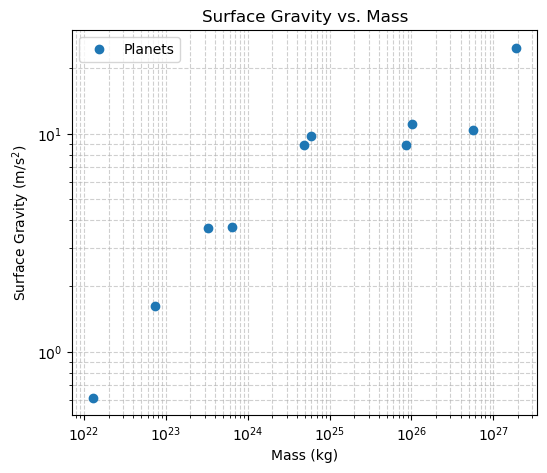

In [18]:
G = const.G
M = df["Mass (kg)"].values * u.kg 
R = (df["Diameter (km)"].values * u.km / 2).to(u.m) 
print(R)

# Compute surface gravity
g = (G * M / R**2).to(u.m / u.s**2)

# Plot
plt.figure(figsize=(6, 5))
plt.loglog(M, g, 'o', label="Planets")
plt.xlabel("Mass (kg)")
plt.ylabel("Surface Gravity (m/s$^2$)")
plt.title("Surface Gravity vs. Mass")
plt.legend()
plt.grid(which="both", ls="--", alpha=0.6)
plt.show()


Best-fit parameters: slope = 0.255, intercept = -5.576
Reduced chi-squared: 0.035


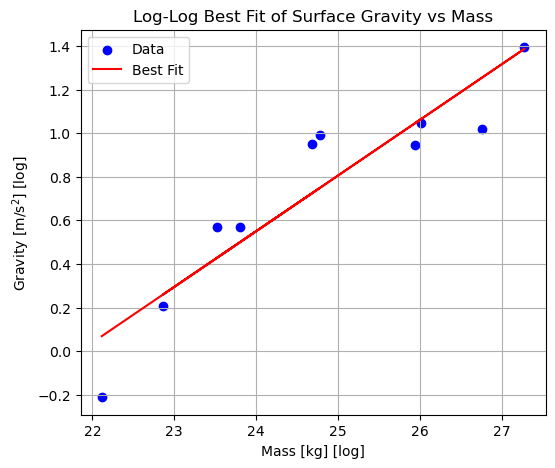

In [19]:
def linear(x, m, b):
    return m * x + b

x = np.log10(M.value)
y = np.log10(g.value)

popt, pcov = curve_fit(linear, x, y)
m_fit, b_fit = popt

y_fit = linear(x, m_fit, b_fit)

residuals = y - y_fit
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
reduced_chi2 = chi2 / dof

print(f"\nBest-fit parameters: slope = {m_fit:.3f}, intercept = {b_fit:.3f}")
print(f"Reduced chi-squared: {reduced_chi2:.3f}")

plt.figure(figsize=(6, 5))
plt.scatter(x, y, label="Data", color="blue")
plt.plot(x, y_fit, color="red", label="Best Fit")
plt.xlabel("Mass [kg] [log]")
plt.ylabel("Gravity [m/s$^2$] [log]")
plt.title("Log-Log Best Fit of Surface Gravity vs Mass")
plt.grid()
plt.legend()
plt.show()

According to the reduced chi-squared metric, it is a good fit

In [20]:
df_save = df.copy(deep=False)

# Convert quantity columns to plain numbers
for col in df_save.columns:
    first_val = df_save[col].iloc[0]
    if isinstance(first_val, u.Quantity):
        df_save[col] = [x.value if isinstance(x, u.Quantity) else np.nan for x in df_save[col]]

df_save.to_csv("units.csv", index=False)